# Phan tich Breast Cancer Gene Expression (BCGE)

Notebook nay xay dung quy trinh phan loai cho du lieu bieu hien gen ung thu vu. Du lieu co rat nhieu dac trung gen nhung so mau it, nen trong tam la chon loc dac trung truoc khi huan luyen mo hinh.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import StratifiedKFold

from src.data_loader import load_bcge_data
from src.feature_analysis import eda_summary
from src.feature_selection import filter_select_kbest, choose_filter_result, wrapper_rfecv
from src.pipeline import make_split, make_cv
from src.preprocessing import preprocess_train_test
from src.classification import train_models_for_versions
from src.evaluation import results_to_dataframe
from src.visualization import (
    plot_class_distribution, plot_correlation_heatmap, plot_tsne, plot_umap,
    plot_model_comparison, plot_feature_importance, plot_learning_curves
)

RANDOM_STATE = 42
BCGE_PATH = PROJECT_ROOT / 'breast'

## 1. EDA

Buoc nay giup nhin tong quan du lieu: so mau, so gen, phan bo nhan benh, gia tri thieu va muc mat can bang lop. Voi BCGE, so dac trung rat lon nen can chu y nguy co qua khop.

In [2]:
X, y = load_bcge_data(BCGE_PATH)
summary = eda_summary(X, y)
print('Shape:', X.shape)
print('Imbalance ratio:', summary['imbalance_ratio'])
display(summary['class_distribution'])
display(summary['missing_values'].query('missing_count > 0').head(20))
display(summary['feature_distributions'].head())

Shape: (151, 54675)
Imbalance ratio: 5.857142857142857


,count,percent
type,,
basal,41,27.152318
HER,30,19.867550
luminal_B,30,19.867550
luminal_A,29,19.205298
cell_line,14,9.271523
normal,7,4.635762


,missing_count,missing_percent


,count,mean,std,min,25%,50%,75%,max
1007_s_at,151.0,10.338901,0.613445,7.505488,10.103030,10.416819,10.735117,11.675109
1053_at,151.0,7.631910,0.706464,5.855968,7.166075,7.531673,8.053832,9.627008
117_at,151.0,6.224885,0.645435,4.763602,5.798087,6.235074,6.612291,8.364749
121_at,151.0,7.339248,0.330827,6.632206,7.105841,7.333426,7.513084,8.374055
1255_g_at,151.0,3.185252,0.158909,2.760583,3.075873,3.187703,3.280416,3.611630


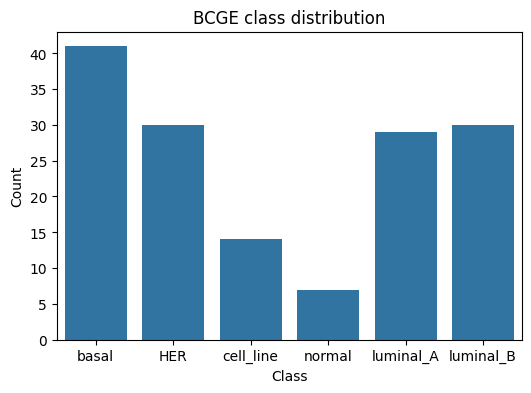

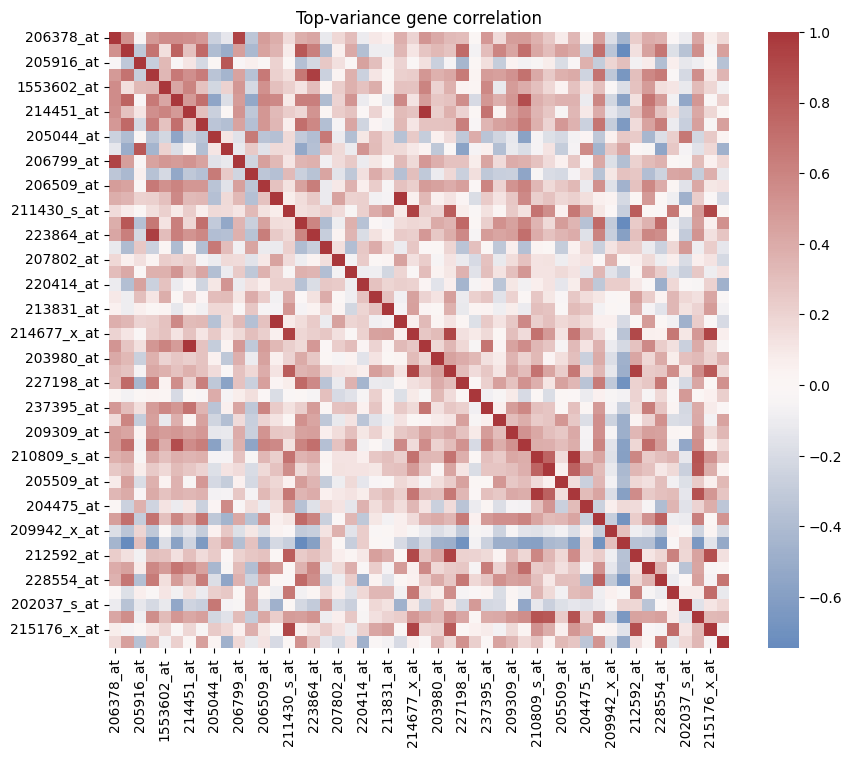

In [3]:
plot_class_distribution(y, 'BCGE class distribution');
plot_correlation_heatmap(summary['correlation_matrix'], 'Top-variance gene correlation');

## 2. Preprocessing

Du lieu duoc chia train/test theo ty le 80/20 va giu ti le lop bang stratified sampling. Median imputation, StandardScaler va LabelEncoder chi duoc fit tren tap train de tranh ro ri du lieu.

In [4]:
X_train, X_test, y_train, y_test = make_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_p, X_test_p, y_train_p, y_test_p, processor = preprocess_train_test(X_train, X_test, y_train, y_test)
cv = make_cv(k=5, random_state=RANDOM_STATE)
print(X_train_p.shape, X_test_p.shape)
print(dict(zip(processor.label_encoder.classes_, range(len(processor.label_encoder.classes_)))))

(120, 54675) (31, 54675)
{'HER': 0, 'basal': 1, 'cell_line': 2, 'luminal_A': 3, 'luminal_B': 4, 'normal': 5}


## 3. Visualization

t-SNE va UMAP nen duoc doc nhu ban do 2D tham khao. Neu cac lop tach nhau theo cum, dieu do goi y quan he phi tuyen trong khong gian gen.

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py:150: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\loky\backend\context.py", line 227, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^

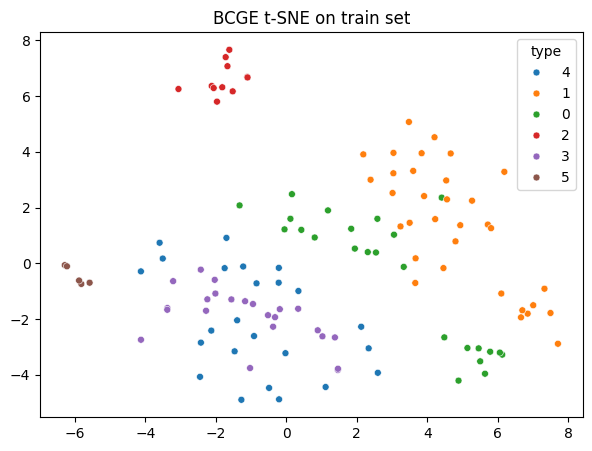

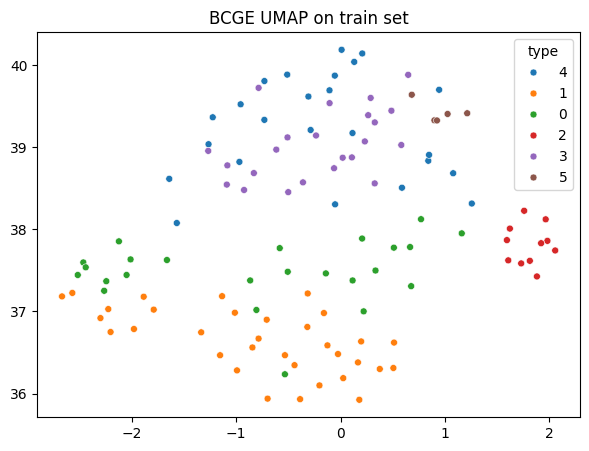

In [5]:
plot_tsne(X_train_p, y_train_p, title='BCGE t-SNE on train set');
plot_umap(X_train_p, y_train_p, title='BCGE UMAP on train set');

## 4. Feature Selection

Day la trong tam cua BCGE vi so gen lon hon rat nhieu so mau. Ta dung hai cach: filter method gom Variance Threshold va SelectKBest voi K = 50, 100, 200, 500; wrapper method dung RFECV voi Random Forest.

In [6]:
filter_results = filter_select_kbest(X_train_p, y_train_p, X_test_p, k_values=(50, 100, 200, 500))
filter_result = choose_filter_result(filter_results, preferred_k=200)
print('Filter selected:', len(filter_result.selected_features))
display(filter_result.scores.head(20))

wrapper_result = wrapper_rfecv(
    filter_result.X_train, y_train_p, filter_result.X_test,
    cv=cv, min_features_to_select=10, step=0.1, random_state=RANDOM_STATE
)
print('Wrapper selected:', len(wrapper_result.selected_features))
display(wrapper_result.ranking.head(20))

Filter selected: 200


,feature,score,p_value
20523,211161_s_at,395.305176,3.002106e-70
11192,201744_s_at,368.636067,1.277957e-68
24370,215076_s_at,340.865870,8.416111e-67
20189,210809_s_at,301.796632,5.412268e-64
11300,201852_x_at,283.302939,1.522704e-62
10243,200795_at,253.062827,5.647899e-60
11852,202404_s_at,199.164658,1.315478e-54
11851,202403_s_at,166.860339,1.000048e-50
37495,228241_at,159.273645,1.016137e-49
11758,202310_s_at,140.836134,4.360520e-47


Wrapper selected: 100


,feature,rank,selected
0,1552509_a_at,1,True
1,1552619_a_at,1,True
3,1555778_a_at,1,True
5,1558447_at,1,True
6,1558448_a_at,1,True
7,1558496_at,1,True
9,1559401_a_at,1,True
11,1563941_at,1,True
13,200795_at,1,True
14,200934_at,1,True


## 5. Resampling

BCGE van di qua buoc danh gia mat can bang lop, nhung day khong phai trong tam chinh. Trong notebook nay, cac thi nghiem BCGE tap trung vao ba phien ban dac trung: original, filter-selected va wrapper-selected.

In [7]:
data_versions = {
    'original': {'X_train': X_train_p, 'y_train': y_train_p, 'X_test': X_test_p},
    'filter-selected': {'X_train': filter_result.X_train, 'y_train': y_train_p, 'X_test': filter_result.X_test},
    'wrapper-selected': {'X_train': wrapper_result.X_train, 'y_train': y_train_p, 'X_test': wrapper_result.X_test},
}
X_test_lookup = {name: version['X_test'] for name, version in data_versions.items()}
list(data_versions.keys())

['original', 'filter-selected', 'wrapper-selected']

## 6. Classification

Moi phien ban du lieu duoc huan luyen voi 5 mo hinh: Logistic Regression, SVM RBF, Random Forest, XGBoost va MLP. GridSearchCV dung Stratified K-Fold 5 folds tren train set.

In [8]:
results = train_models_for_versions(
    data_versions, X_test_p, y_test_p,
    cv=cv, random_state=RANDOM_STATE, scoring='f1_weighted', experiment_prefix='BCGE | '
)
results_df = results_to_dataframe(results)
display(results_df)

,experiment,data_version,model,best_params,cv_f1,test_accuracy,test_f1,test_roc_auc
14,BCGE | wrapper-selected | MLP,wrapper-selected,MLP,"{'hidden_layer_sizes': (64,), 'learning_rate_i...",0.945262,0.967742,0.967907,1.000000
5,BCGE | filter-selected | Logistic Regression,filter-selected,Logistic Regression,"{'C': 0.1, 'solver': 'lbfgs'}",0.974266,0.967742,0.967516,1.000000
10,BCGE | wrapper-selected | Logistic Regression,wrapper-selected,Logistic Regression,"{'C': 1, 'solver': 'lbfgs'}",0.974266,0.967742,0.967516,1.000000
11,BCGE | wrapper-selected | SVM RBF,wrapper-selected,SVM RBF,"{'C': 10, 'gamma': 'scale'}",0.991349,0.967742,0.967516,1.000000
12,BCGE | wrapper-selected | Random Forest,wrapper-selected,Random Forest,"{'max_depth': None, 'n_estimators': 100}",0.956381,0.967742,0.967516,0.998710
6,BCGE | filter-selected | SVM RBF,filter-selected,SVM RBF,"{'C': 1, 'gamma': 'scale'}",0.983016,0.967742,0.967516,0.996129
2,BCGE | original | Random Forest,original,Random Forest,"{'max_depth': None, 'n_estimators': 200}",0.956571,0.967742,0.963606,0.998065
7,BCGE | filter-selected | Random Forest,filter-selected,Random Forest,"{'max_depth': None, 'n_estimators': 200}",0.956597,0.935484,0.937551,0.999355
0,BCGE | original | Logistic Regression,original,Logistic Regression,"{'C': 0.1, 'solver': 'lbfgs'}",0.921999,0.935484,0.935424,0.996129
8,BCGE | filter-selected | XGBoost,filter-selected,XGBoost,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",0.936811,0.903226,0.905647,0.993548


## 7. Evaluation

Ket qua bao gom Accuracy, F1-score, ROC-AUC va confusion matrix. Voi bai toan nhieu lop, F1 weighted giup danh gia cong bang hon khi cac lop co kich thuoc khac nhau.

experiment                           BCGE | wrapper-selected | MLP
test_accuracy                                             0.967742
test_f1                                                   0.967907
test_roc_auc                                                   1.0
best_params      {'hidden_layer_sizes': (64,), 'learning_rate_i...
Name: 14, dtype: object
[[6 0 0 0 0 0]
 [0 7 0 0 1 0]
 [0 0 3 0 0 0]
 [0 0 0 6 0 0]
 [0 0 0 0 6 0]
 [0 0 0 0 0 2]]


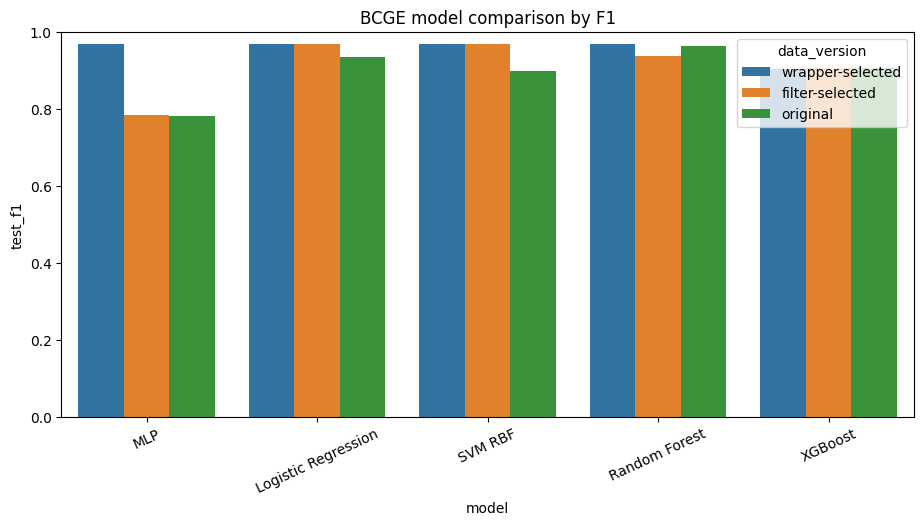

In [9]:
plot_model_comparison(results_df, metric='test_f1', title='BCGE model comparison by F1');
best = results_df.iloc[0]
best_result = next(r for r in results if r['experiment'] == best['experiment'])
print(best[['experiment', 'test_accuracy', 'test_f1', 'test_roc_auc', 'best_params']])
print(best_result['metrics']['confusion_matrix'])

## 8. Feature Importance va Learning Curves

Feature importance cho biet nhung gen nao dong gop manh vao mo hinh tot nhat. Learning curves so sanh LR, RF va XGBoost; neu LR dat tran thap hon ro ret, day la bang chung thuc nghiem rang mo hinh tuyen tinh khong du manh cho du lieu nay.

C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\PAVILION\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\loc

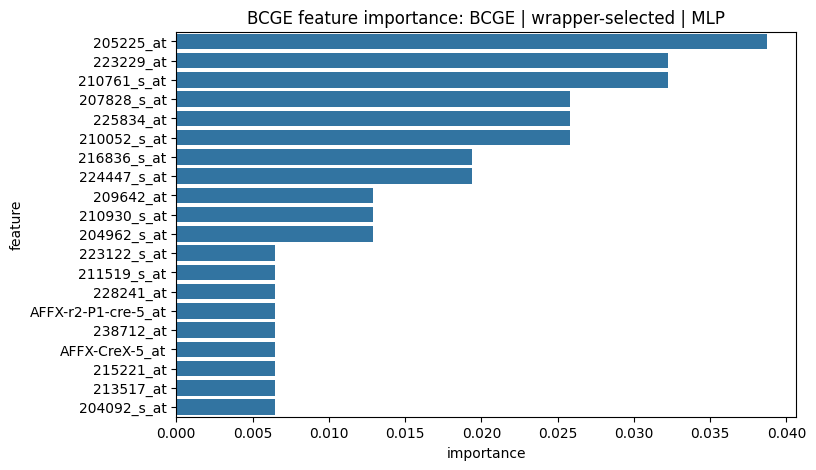

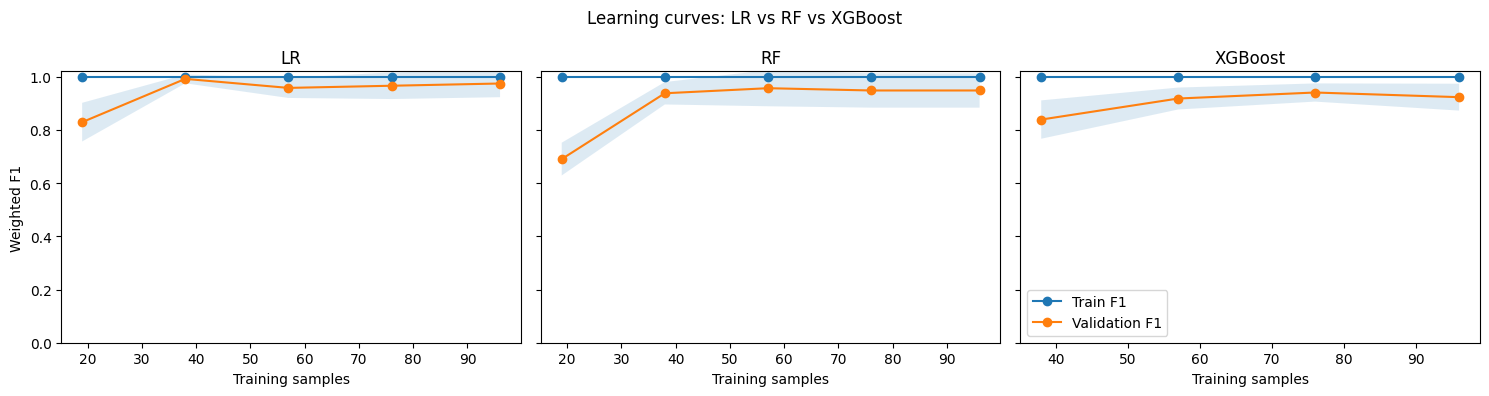

In [10]:
best_version = best_result['data_version']
best_X_test = X_test_lookup[best_version]
plot_feature_importance(
    best_result['best_estimator'], best_X_test, y_test_p,
    top_n=20, title=f"BCGE feature importance: {best['experiment']}"
);
plot_learning_curves(
    data_versions[best_version]['X_train'], data_versions[best_version]['y_train'],
    cv=cv, random_state=RANDOM_STATE
);